# 📊 RADAR DIGITAL - EVALUACIÓN DE MODELOS

## Notebook para evaluar los modelos entrenados

### Modelos disponibles:
- **Clasificador** (TabNet) - Accuracy, Precision, Recall, F1, Matriz de Confusión
- **Predictor** (XGBoost) - MSE, RMSE, MAE, R², Gráficos de error
- **Explicador** (MLP) - MAE, R²
- **Generador** (MLP + Reglas) - MSE, RMSE, MAE, R²

### Configuración:
Cambia `MODELO_A_EVALUAR` para elegir qué modelo evaluar.

Opciones: `"clasificador"`, `"predictor"`, `"explicador"`, `"generador"`, `"todos"`

In [33]:
# CONFIGURACIÓN - ELIGE QUÉ EVALUAR

# Opciones: "clasificador" | "predictor" | "explicador" | "generador" | "todos"
MODELO_A_EVALUAR = "todos"

# 1. IMPORTAR DEPENDENCIAS

import sys
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# Agregar ruta raíz
ROOT_DIR = Path().resolve().parent
sys.path.append(str(ROOT_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)

from utils import cargar_artefactos, get_device, set_seed

# Importar modelos
from models.clasificador import ClasificadorTabNet, cargar_datos as cargar_datos_clasificador, preparar_datos as preparar_datos_clasificador
from models.predictor import PredictorXGBoost, cargar_datos as cargar_datos_predictor, preparar_datos as preparar_datos_predictor
from models.explicador import Explicador, cargar_datos as cargar_datos_explicador, preparar_datos as preparar_datos_explicador
from models.generador import Generador

print("✅ Dependencias importadas correctamente")

✅ Dependencias importadas correctamente


In [34]:
# 2. CONFIGURACIÓN INICIAL

set_seed(42)
device = get_device()
ARTIFACTS_DIR = ROOT_DIR / 'datasets' / 'artifacts'
CHECKPOINT_DIR = ROOT_DIR / 'checkpoints'
RESULTADOS_DIR = ROOT_DIR / 'resultados_evaluaciones'

# Cargar artefactos
scaler, label_encoder, feature_columns, class_mapping, class_names = cargar_artefactos(ARTIFACTS_DIR)

print(f"📱 Dispositivo: {device}")
print(f"📊 Features: {len(feature_columns)} variables")
print(f"📋 Clases: {class_names}")

✅ Semilla fijada a 42
✅ GPU disponible: NVIDIA GeForce RTX 3050 6GB Laptop GPU
   Memoria GPU: 6.22 GB
✅ Artefactos cargados:
   - Features: 18 variables
   - Clases: ['None', 'Mild', 'Moderate', 'Severe']
📱 Dispositivo: cuda
📊 Features: 18 variables
📋 Clases: ['None', 'Mild', 'Moderate', 'Severe']


In [35]:
# 3. FUNCIONES DE EVALUACIÓN

def evaluar_clasificador():
    """Evalúa el clasificador TabNet."""
    print("\n" + "=" * 60)
    print("📊 EVALUANDO CLASIFICADOR")
    print("=" * 60)
    
    X, y, _, class_names = cargar_datos_clasificador()
    _, _, _, _, X_test, y_test = preparar_datos_clasificador(X, y)
    
    clasificador = ClasificadorTabNet(device=str(device))
    clasificador.cargar_checkpoint()
    
    y_pred = clasificador.predecir(X_test)
    
    # Métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"\n📊 Métricas:")
    print(f"   ✅ Accuracy: {accuracy:.4f}")
    print(f"   ✅ Precision: {precision:.4f}")
    print(f"   ✅ Recall: {recall:.4f}")
    print(f"   ✅ F1-score: {f1:.4f}")
    
    print("\n📋 Reporte de clasificación:")
    print(classification_report(y_test, y_pred, target_names=class_names))
    
    # Graficar matriz de confusión
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title('Matriz de Confusión (Absoluta)')
    axes[0].set_xlabel('Predicción')
    axes[0].set_ylabel('Real')
    
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title('Matriz de Confusión (Normalizada)')
    axes[1].set_xlabel('Predicción')
    axes[1].set_ylabel('Real')
    
    plt.tight_layout()
    plt.savefig(RESULTADOS_DIR / 'evaluacion_clasificador.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Mostrar feature importance - MANEJO DE ERROR
    try:
        importancias = clasificador.get_feature_importance()
        if importancias is not None and len(importancias) > 0:
            indices = np.argsort(importancias)[::-1][:5]
            print("\n📊 Top 5 características más importantes:")
            for i, idx in enumerate(indices):
                print(f"   {i+1}. {feature_columns[idx]}: {importancias[idx]:.4f}")
        else:
            print("\n⚠️ No se pudieron obtener las importancias de características.")
    except Exception as e:
        print(f"\n⚠️ Error al obtener importancias: {e}")
        print("   (Esto es normal para TabNet, no afecta las métricas principales)")
    
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def evaluar_predictor():
    """Evalúa el predictor XGBoost."""
    print("\n" + "=" * 60)
    print("📊 EVALUANDO PREDICTOR")
    print("=" * 60)
    
    X, y, _ = cargar_datos_predictor()
    _, _, _, _, X_test, y_test = preparar_datos_predictor(X, y)
    
    predictor = PredictorXGBoost()
    predictor.cargar_checkpoint()
    predictor.feature_names = feature_columns
    
    y_pred = predictor.predecir(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"\n📊 Métricas:")
    print(f"   ✅ MSE: {mse:.4f}")
    print(f"   ✅ RMSE: {rmse:.4f}")
    print(f"   ✅ MAE: {mae:.4f}")
    print(f"   ✅ R²: {r2:.4f}")
    
    # Gráficos
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].scatter(y_test, y_pred, alpha=0.3)
    axes[0].plot([0, 1], [0, 1], 'r--', label='Predicción perfecta')
    axes[0].set_xlabel('Riesgo real')
    axes[0].set_ylabel('Riesgo predicho')
    axes[0].set_title('Predicciones vs Reales')
    axes[0].legend()
    axes[0].grid(True)
    
    errores = y_pred - y_test
    axes[1].hist(errores, bins=30, edgecolor='black')
    axes[1].axvline(x=0, color='r', linestyle='--', label='Error cero')
    axes[1].set_xlabel('Error de predicción')
    axes[1].set_ylabel('Frecuencia')
    axes[1].set_title('Distribución de errores')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.savefig(RESULTADOS_DIR / 'evaluacion_predictor.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Mostrar feature importance
    importancias = predictor.get_feature_importance()
    if importancias is not None and len(importancias) > 0:
        indices = np.argsort(importancias)[::-1][:5]
        print("\n📊 Top 5 características más importantes:")
        for i, idx in enumerate(indices):
            print(f"   {i+1}. {feature_columns[idx]}: {importancias[idx]:.4f}")
    
    return {"mse": mse, "rmse": rmse, "mae": mae, "r2": r2}


def evaluar_explicador():
    """Evalúa el explicador MLP."""
    print("\n" + "=" * 60)
    print("📊 EVALUANDO EXPLICADOR")
    print("=" * 60)
    
    X, y, _ = cargar_datos_explicador()
    _, _, _, _, X_test, y_test = preparar_datos_explicador(X, y)
    
    explicador = Explicador(device=device)
    explicador.cargar_checkpoint()
    explicador.feature_names = feature_columns
    
    y_pred = explicador.predecir_importancias(X_test)
    
    # Verificar dimensiones
    print(f"\n📐 Dimensiones:")
    print(f"   y_test shape: {y_test.shape}")
    print(f"   y_pred shape: {y_pred.shape}")
    
    if y_pred.ndim == 2 and y_pred.shape[1] > 1:
        if y_test.ndim == 1:
            print("\n🔄 Expandiendo y_test para que coincida con y_pred...")
            y_test_expanded = np.tile(y_test.reshape(-1, 1), (1, y_pred.shape[1]))

        # Calcular métricas por cada característica
        mae_por_feature = mean_absolute_error(y_test_expanded, y_pred, multioutput='raw_values')
        r2_por_feature = r2_score(y_test_expanded, y_pred, multioutput='raw_values')
        
        mae_promedio = np.mean(mae_por_feature)
        r2_promedio = np.mean(r2_por_feature)
        
        print(f"\n📊 Métricas promedio (sobre {y_pred.shape[1]} características):")
        print(f"   ✅ MAE promedio: {mae_promedio:.4f}")
        print(f"   ✅ R² promedio: {r2_promedio:.4f}")
        
        # Mostrar estadísticas de las características
        print("\n📊 Estadísticas por característica:")
        for i, (mae_i, r2_i) in enumerate(zip(mae_por_feature, r2_por_feature)):
            print(f"   {i+1:2d}. {feature_columns[i]:25s} MAE={mae_i:.4f}, R²={r2_i:.4f}")
        
        return {"mae": mae_promedio, "r2": r2_promedio}
    
    # CASO 2: El modelo predice una sola salida
    else:
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        print(f"\n📊 Métricas:")
        print(f"   ✅ MAE: {mae:.4f}")
        print(f"   ✅ R²: {r2:.4f}")
        
        return {"mae": mae, "r2": r2}


def evaluar_generador():
    """Evalúa el generador MLP."""
    print("\n" + "=" * 60)
    print("📊 EVALUANDO GENERADOR")
    print("=" * 60)
    
    # Cargar corpus de prueba
    corpus_path = CHECKPOINT_DIR / 'generador' / 'corpus_sintetico.csv'
    corpus = pd.read_csv(corpus_path)
    
    # Extraer features y target
    X_test = np.array([np.fromstring(row.strip('[]'), sep=' ') for row in corpus['features'].values])
    y_test = corpus['urgencia'].values
    
    generador = Generador(device=device)
    generador.cargar_checkpoint()
    
    y_pred = generador.predecir_urgencia(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"\n📊 Métricas:")
    print(f"   ✅ MSE: {mse:.4f}")
    print(f"   ✅ RMSE: {rmse:.4f}")
    print(f"   ✅ MAE: {mae:.4f}")
    print(f"   ✅ R²: {r2:.4f}")
    
    # Gráfico de predicciones vs reales
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].scatter(y_test, y_pred, alpha=0.3)
    axes[0].plot([0, 1], [0, 1], 'r--', label='Predicción perfecta')
    axes[0].set_xlabel('Urgencia real')
    axes[0].set_ylabel('Urgencia predicha')
    axes[0].set_title('Predicciones vs Reales')
    axes[0].legend()
    axes[0].grid(True)
    
    errores = y_pred - y_test
    axes[1].hist(errores, bins=30, edgecolor='black')
    axes[1].axvline(x=0, color='r', linestyle='--', label='Error cero')
    axes[1].set_xlabel('Error de predicción')
    axes[1].set_ylabel('Frecuencia')
    axes[1].set_title('Distribución de errores')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.savefig(RESULTADOS_DIR / 'evaluacion_generador.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return {"mse": mse, "rmse": rmse, "mae": mae, "r2": r2}


print("✅ Funciones de evaluación definidas")

✅ Funciones de evaluación definidas



📊 EVALUANDO TODOS LOS MODELOS

📊 EVALUANDO CLASIFICADOR
📂 CARGANDO DATOS
✅ Dataset cargado: 7500 registros, 25 columnas
✅ Features: 18 variables
✅ Target: addiction_level_encoded
✅ Clases: ['None', 'Mild', 'Moderate', 'Severe']

📊 PREPARANDO DATOS
✅ Entrenamiento: 4500 registros
✅ Validación: 1500 registros
✅ Prueba: 1500 registros

📊 Distribución de clases en entrenamiento:
   Clase 0: 491 (10.9%)
   Clase 1: 825 (18.3%)
   Clase 2: 1724 (38.3%)
   Clase 3: 1460 (32.4%)
✅ Modelo TabNet cargado desde: /home/sarzuricarlos60/Desktop/Proyecto_Habitos_Digitales/checkpoints/clasificador
   - Clases: ['None', 'Mild', 'Moderate', 'Severe']
   - Features: 18
   - Versión: tabnet_v1

📊 Métricas:
   ✅ Accuracy: 0.5253
   ✅ Precision: 0.5274
   ✅ Recall: 0.5253
   ✅ F1-score: 0.4983

📋 Reporte de clasificación:
              precision    recall  f1-score   support

        None       0.53      0.84      0.65       164
        Mild       0.55      0.51      0.53       274
    Moderate       0.53 

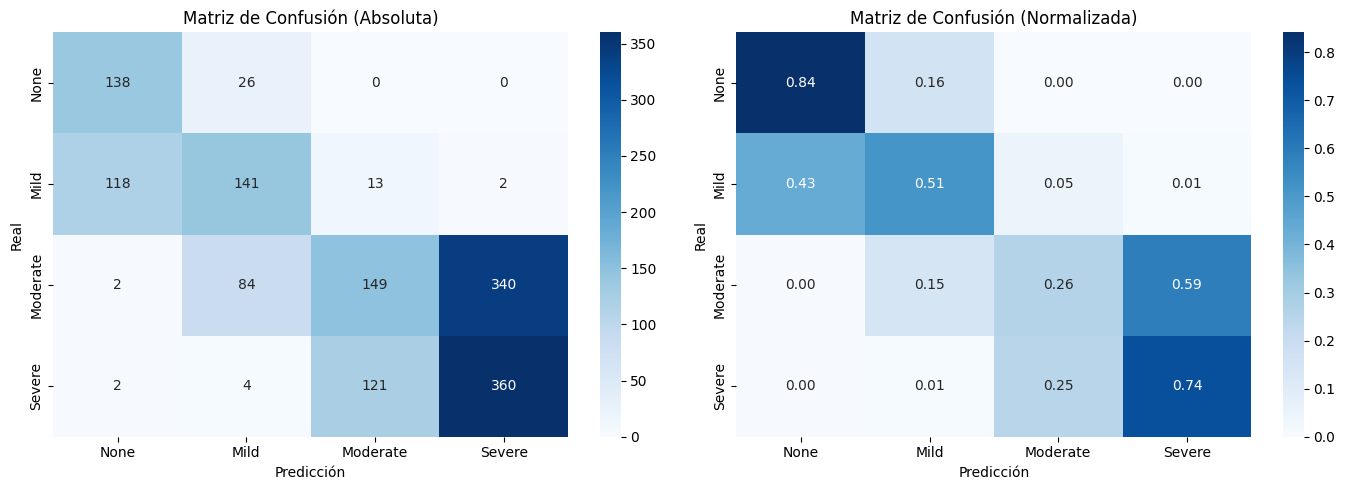


⚠️ Error al obtener importancias: 'TabNetClassifier' object has no attribute 'feature_importances_'
   (Esto es normal para TabNet, no afecta las métricas principales)

📊 EVALUANDO PREDICTOR
📂 CARGANDO DATOS
✅ Dataset cargado: 7500 registros, 25 columnas
✅ Features: 18 variables

📊 Calculando riesgo compuesto (target)...
   Min: 0.000, Max: 0.794, Media: 0.339

📊 PREPARANDO DATOS
✅ Entrenamiento: 4500 registros
✅ Validación: 1500 registros
✅ Prueba: 1500 registros
✅ Modelo XGBoost cargado desde: /home/sarzuricarlos60/Desktop/Proyecto_Habitos_Digitales/checkpoints/predictor
   - Features: 18

📊 Métricas:
   ✅ MSE: 0.0001
   ✅ RMSE: 0.0097
   ✅ MAE: 0.0076
   ✅ R²: 0.9953


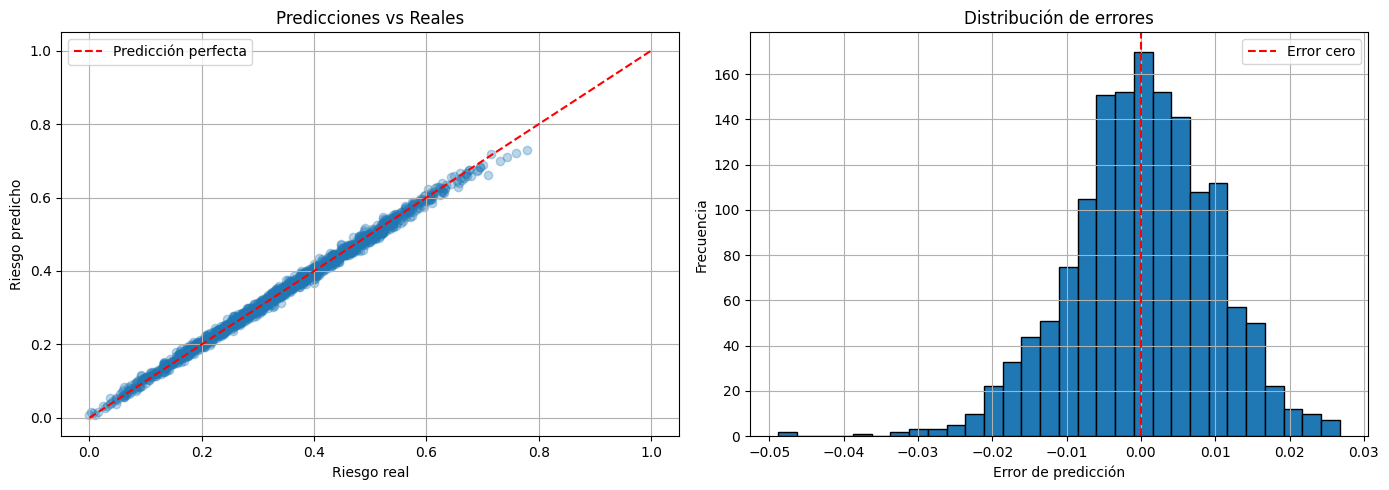


📊 Top 5 características más importantes:
   1. sleep_screen_imbalance: 0.4328
   2. social_media_hours: 0.1717
   3. total_usage_composite: 0.1358
   4. sleep_hours: 0.0779
   5. social_media_ratio: 0.0457

📊 EVALUANDO EXPLICADOR
📂 CARGANDO DATOS
✅ Dataset cargado: 7500 registros, 25 columnas
✅ Features: 18 variables

📊 PREPARANDO DATOS
✅ Entrenamiento: 4500 registros
✅ Validación: 1500 registros
✅ Prueba: 1500 registros
✅ Modelo explicador cargado desde: /home/sarzuricarlos60/Desktop/Proyecto_Habitos_Digitales/checkpoints/explicador
   - Features: 18

📐 Dimensiones:
   y_test shape: (1500,)
   y_pred shape: (1500, 18)

🔄 Expandiendo y_test para que coincida con y_pred...

📊 Métricas promedio (sobre 18 características):
   ✅ MAE promedio: 1.8462
   ✅ R² promedio: -3.5196

📊 Estadísticas por característica:
    1. daily_screen_time_hours   MAE=1.7125, R²=-2.8893
    2. social_media_hours        MAE=1.7205, R²=-2.9154
    3. gaming_hours              MAE=1.8752, R²=-3.6621
    4. work_s

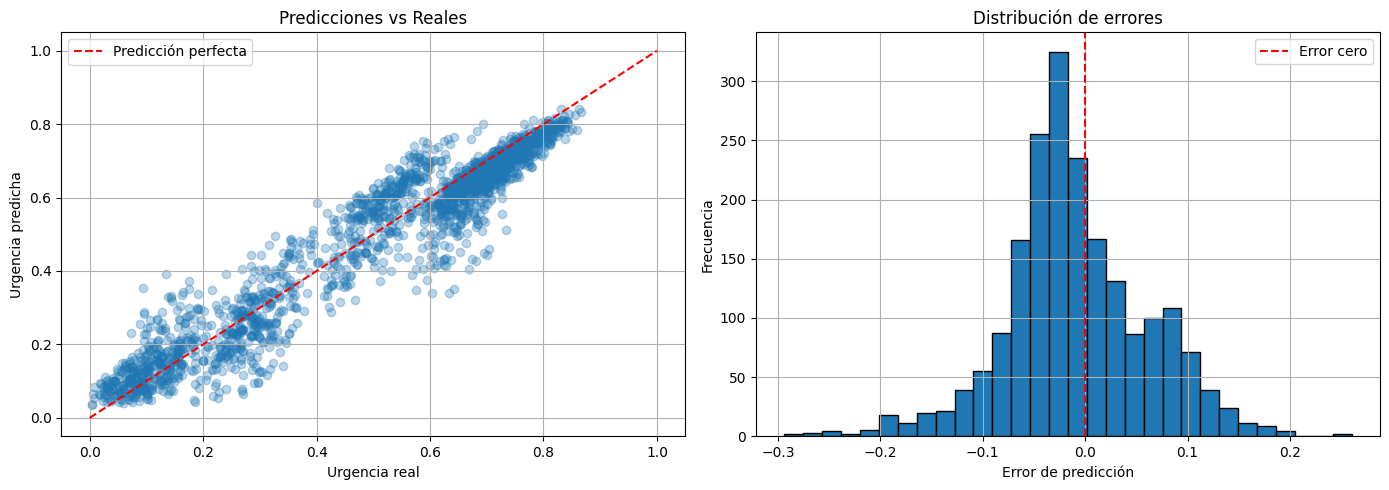

In [36]:
# 4. EJECUTAR EVALUACIÓN

resultados = {}
modelos_disponibles = {
    "clasificador": evaluar_clasificador,
    "predictor": evaluar_predictor,
    "explicador": evaluar_explicador,
    "generador": evaluar_generador
}

if MODELO_A_EVALUAR == "todos":
    print("\n" + "=" * 60)
    print("📊 EVALUANDO TODOS LOS MODELOS")
    print("=" * 60)
    for nombre, func in modelos_disponibles.items():
        try:
            resultados[nombre] = func()
        except Exception as e:
            resultados[nombre] = {"error": str(e), "status": "❌ ERROR"}
else:
    if MODELO_A_EVALUAR in modelos_disponibles:
        try:
            resultados[MODELO_A_EVALUAR] = modelos_disponibles[MODELO_A_EVALUAR]()
        except Exception as e:
            resultados[MODELO_A_EVALUAR] = {"error": str(e), "status": "❌ ERROR"}
    else:
        print(f"❌ Modelo '{MODELO_A_EVALUAR}' no reconocido")
        print("Opciones: clasificador, predictor, explicador, generador, todos")

In [37]:
# 5. RESUMEN FINAL

print("\n" + "=" * 60)
print("📊 RESUMEN DE EVALUACIÓN")
print("=" * 60)

for modelo, metricas in resultados.items():
    print(f"\n📋 {modelo.upper()}:")
    if "error" in metricas:
        print(f"   ❌ Error: {metricas['error']}")
    else:
        for metrica, valor in metricas.items():
            if isinstance(valor, (int, float)):
                print(f"   {metrica}: {valor:.4f}")
            else:
                print(f"   {metrica}: {valor}")

# Guardar resultados
def convertir_a_nativo(obj):
    """Convierte NumPy types a Python types."""
    if isinstance(obj, (np.integer, np.int_)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float_)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {key: convertir_a_nativo(value) for key, value in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [convertir_a_nativo(item) for item in obj]
    else:
        return obj

# Convertir y guardar
resultados_convertidos = convertir_a_nativo(resultados)
with open(RESULTADOS_DIR / 'resultados_evaluacion.json', 'w') as f:
    json.dump(resultados_convertidos, f, indent=4)

# Crear tabla comparativa
tabla = []
for modelo, metricas in resultados.items():
    if "error" not in metricas:
        fila = {"Modelo": modelo}
        fila.update({k: round(v, 4) for k, v in metricas.items() if isinstance(v, (int, float))})
        tabla.append(fila)

if tabla:
    df_tabla = pd.DataFrame(tabla)
    print("\n" + "=" * 60)
    print("📊 TABLA COMPARATIVA")
    print("=" * 60)
    print(df_tabla.to_string(index=False))

print("\n" + "=" * 60)
print("✅ Evaluación completada!")
print(f"📂 Resultados guardados en: {RESULTADOS_DIR}/resultados_evaluacion.json")
print("=" * 60)


📊 RESUMEN DE EVALUACIÓN

📋 CLASIFICADOR:
   accuracy: 0.5253
   precision: 0.5274
   recall: 0.5253
   f1: 0.4983

📋 PREDICTOR:
   mse: 0.0001
   rmse: 0.0097
   mae: 0.0076
   r2: 0.9953

📋 EXPLICADOR:
   mae: 1.8462
   r2: -3.5196077823638916

📋 GENERADOR:
   mse: 0.0050
   rmse: 0.0709
   mae: 0.0548
   r2: 0.9168

📊 TABLA COMPARATIVA
      Modelo  accuracy  precision  recall     f1    mse   rmse    mae     r2
clasificador    0.5253     0.5274  0.5253 0.4983    NaN    NaN    NaN    NaN
   predictor       NaN        NaN     NaN    NaN 0.0001 0.0097 0.0076 0.9953
  explicador       NaN        NaN     NaN    NaN    NaN    NaN 1.8462    NaN
   generador       NaN        NaN     NaN    NaN 0.0050 0.0709 0.0548 0.9168

✅ Evaluación completada!
📂 Resultados guardados en: /home/sarzuricarlos60/Desktop/Proyecto_Habitos_Digitales/resultados_evaluaciones/resultados_evaluacion.json
